In [1]:
import salvus.namespace as sn
import numpy as np
from my_code.utilities import *
from pathlib import Path
import salvus
import salvus.mesh.layered_meshing as lm
from datetime import datetime
import math
import xarray as xr

# # Directories in WSL
# PROJECT_DIR = '/home/oliver/workspace/Salvus/acoustic_model/Project'
# IMAGE_DIR = '/home/oliver/workspace/Salvus/acoustic_model/image'
# DATA_DIR = '/home/oliver/workspace/Salvus/acoustic_model/data'


# Directories in Windows
PROJECT_DIR_WIN = '/mnt/d/Salvus_project/acoustic_model/Project'
DATA_DIR_WIN = '/mnt/d/Salvus_project/acoustic_model/data'
IMAGE_DIR_WIN = '/mnt/d/Salvus_project/acoustic_model/image'


# create dir if it does not exist

Path(PROJECT_DIR_WIN).mkdir(parents=True, exist_ok=True)
Path(IMAGE_DIR_WIN).mkdir(parents=True, exist_ok=True)
Path(DATA_DIR_WIN).mkdir(parents=True, exist_ok=True)


--> Server: 'https://l.mondaic.com/licensing_server', User: 'bristol.support', Group: 'UniversityOfBristol'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.44 seconds]


In [26]:
# salvus site 
SITE_NAME = "oliver_wsl"
RANKS = 8

CENTRAL_FREQUENCY = 2e4  # Hz
f_c = 2e4  # central frequency in Hz
PROJECT_NAME = 'acoustic_forward'


VP = 5000.0
RHO = 2600.0


x0, x1 = 0.0, 1
y0, y1 = 0.0, 1


domain = sn.domain.dim2.BoxDomain(x0=x0, x1=x1, y0=y0, y1=y1)

p = sn.Project.from_domain(
    path=Path(PROJECT_DIR_WIN, PROJECT_NAME), domain=domain, load_if_exists=True
)



# # Define layers
# layer_ls = [{ 'rho': RHO, 'vp': VP , 'd':1.0}, { 'rho': RHO, 'vp': VP*1.1 , 'd':2.0}, { 'rho': RHO, 'vp': VP*1.3 , 'd':2.0}, { 'rho': RHO, 'vp': VP*1.5 , 'd':2.0}]

# hyperplane_ls = np.cumsum([layer['d'] for layer in layer_ls][::-1])


# layered_model_ls = []

# for i in range(len(layer_ls)):
#     layered_model_ls.append(sn.material.acoustic.Velocity.from_params(rho=layer_ls[i]['rho'], vp=layer_ls[i]['vp']))
#     layered_model_ls.append(sn.layered_meshing.interface.Hyperplane.at(hyperplane_ls[i]))

# layered_model_ls.pop() # delete the last hyperplane


# layered_model = lm.LayeredModel(layered_model_ls)


vp_grad = xr.DataArray(
    np.linspace(1.0, 1.5, 6), [("y", np.linspace(1.0, 0.0, 6))]
)


m1 = sn.material.from_params(rho=RHO, vp=VP*vp_grad)



# mesh resolution parameters
elements_per_wavelength = 3  # number of elements per wavelength
model_order = 4  # model order for the mesh


# absorbing boundary parameters
reference_velocity = 5000           # wave velocity in the absorbing boundary layer
number_of_wavelengths=2            # number of wavelengths to pad the domain by
reference_frequency = f_c*2           # reference frequency for the distance calculation
free_surfaces = ['y0', 'y1']       # free surfaces, absorbing boundaries are applied for the rest






m_homo = sn.material.from_params(rho=RHO, vp=VP)

# adding absorbing boundary conditions to the layered model
model_ab_homo = sn.layered_meshing.MeshingProtocol(
    m_homo,
    ab=salvus.mesh.simple_mesh.basic_mesh.AbsorbingBoundaryParameters(
        free_surface=free_surfaces,
        number_of_wavelengths=number_of_wavelengths,
        reference_velocity=reference_velocity,
        reference_frequency=reference_frequency,
    ),
)

# create mesh 
mesh_homo = lm.mesh_from_domain(
    domain=domain,
    model=model_ab_homo,
    mesh_resolution=sn.MeshResolution(
        reference_frequency=reference_frequency, elements_per_wavelength=elements_per_wavelength, model_order=model_order
    ),
)





# adding absorbing boundary conditions to the layered model
model_ab = sn.layered_meshing.MeshingProtocol(
    m1,
    ab=salvus.mesh.simple_mesh.basic_mesh.AbsorbingBoundaryParameters(
        free_surface=free_surfaces,
        number_of_wavelengths=number_of_wavelengths,
        reference_velocity=reference_velocity,
        reference_frequency=reference_frequency,
    ),
)


# create mesh 
mesh = lm.mesh_from_domain(
    domain=domain,
    model=model_ab,
    mesh_resolution=sn.MeshResolution(
        reference_frequency=reference_frequency, elements_per_wavelength=elements_per_wavelength, model_order=model_order
    ),
)

mesh_homo

Accordion()

In [27]:
aplitude_ratio=1e5

s_loc = (0.7, 1.0)
r_loc = (0.2, 0.2)

receiver = sn.simple_config.receiver.cartesian.Point2D(x=r_loc[0], y=r_loc[1], station_code="R1", fields=["phi"])   

receivers = [receiver, sn.simple_config.receiver.cartesian.Point2D(x=s_loc[0], y=s_loc[1], station_code="Source", fields=["phi"])]

source = sn.simple_config.source.cartesian.ScalarPoint2D(x=s_loc[0], y=s_loc[1], f=aplitude_ratio)


p.add_to_project(
    sn.Event(event_name="event_singlepair", sources=source, receivers=receivers)
)


In [49]:
"""
Configuration from parameters

"""

end_time = 5e-4
start_time= 0
sampling_rate_in_hertz = CENTRAL_FREQUENCY* 100 

time_shift_in_seconds=1/f_c
# simulation of homogeneous model
simulation_name = 'forward_simulation_homogeneous_model'

wavelet = sn.simple_config.stf.Ricker(center_frequency=f_c, time_shift_in_seconds=time_shift_in_seconds)     # wavelet (input source time function) 
# wavelet = sn.simple_config.stf.Ricker(center_frequency=f_c)     # wavelet (input source time function) 



# waveform simulation configuration
waveform_config = sn.WaveformSimulationConfiguration(
        start_time_in_seconds=start_time,
        end_time_in_seconds=end_time,
        time_step_in_seconds=1/sampling_rate_in_hertz
        )

# event configuaration
event_config = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=waveform_config,
    )



sim_config = sn.UnstructuredMeshSimulationConfiguration(
    unstructured_mesh=mesh_homo,
    name=simulation_name,
    event_configuration=event_config,
    )



# add simulation configuration to Project
p.add_to_project(
    sim_config, overwrite=True
    )











# simulation of layered model 
simulation_name = 'forward_simulation_layred_model'



# waveform simulation configuration
waveform_config = sn.WaveformSimulationConfiguration(
        start_time_in_seconds=start_time,
        end_time_in_seconds=end_time,
            time_step_in_seconds=1/sampling_rate_in_hertz

        )

# event configuaration
event_config = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=waveform_config,
    )



sim_config = sn.UnstructuredMeshSimulationConfiguration(
    unstructured_mesh=mesh,
    name=simulation_name,
    event_configuration=event_config,
    )



# add simulation configuration to Project
p.add_to_project(
    sim_config, overwrite=True
    )


# visualization of mesh and simulation set-up
p.viz.nb.simulation_setup(
    simulation_configuration=simulation_name, events=p.events.list()
    )







[2026-03-18 17:08:49,029] INFO: Deleting existing `forward_simulation_homogeneous_model` entity of type `simulation_configuration` ...
[2026-03-18 17:08:49,189] INFO: Deleting existing `forward_simulation_layred_model` entity of type `simulation_configuration` ...


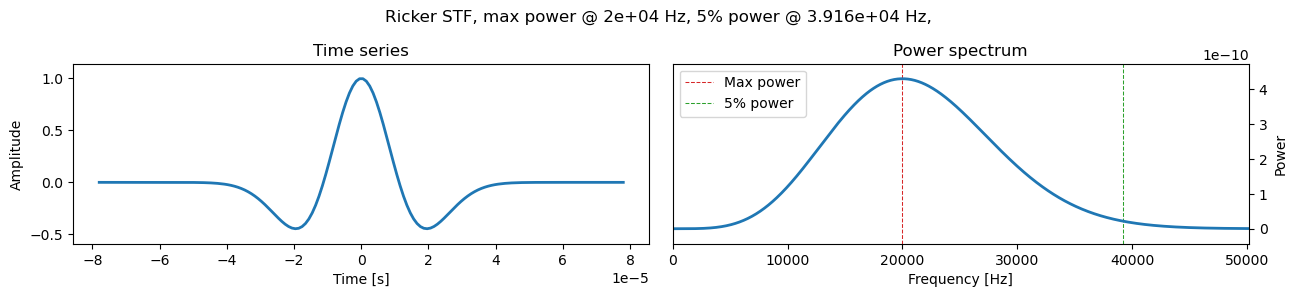

In [11]:
wavelet.plot()

In [50]:
# dofs =  mesh.number_of_nodes
# print(f'Start simulation: {simulation_name}')
# print(f'Dofs (number of nodes): {dofs}')


# simulation_name = 'forward_simulation_homogeneous_model'
simulation_name = 'forward_simulation_layred_model'



"""
Launch simulations

"""

start_time = datetime.now()


p.simulations.launch(
    ranks_per_job=RANKS,
    site_name=SITE_NAME,
    events=p.events.list(),
    simulation_configuration=simulation_name,
    delete_conflicting_previous_results=True,
    )


# # simulation with volume data (full wavefield)
# p.simulations.launch(
#     ranks_per_job=RANKS,
#     site_name=SITE_NAME,
#     events=p.events.list(),
#     simulation_configuration=simulation_name,
#     extra_output_configuration={
#         "volume_data": {
#             "sampling_interval_in_time_steps": 10,
#             "fields": ["phi"],
#         },
#     },
#     # We have previously simulated the same event but without
#     # extra output. We have to thus overwrite the existing
#     # simulation.
#     delete_conflicting_previous_results=True,
# )



p.simulations.query(block=True)


end_time = datetime.now()


execution_time_seconds = (end_time - start_time).total_seconds()
minutes = int(execution_time_seconds // 60)  # Extract minutes
seconds = execution_time_seconds % 60  # Extract remaining seconds

print(f"Execution time: {minutes} minutes and {seconds:.2f} seconds")

[2026-03-18 17:09:13,154] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2603181709259614_2d55b26811@oliver_wsl


VBox()

Execution time: 0 minutes and 3.67 seconds


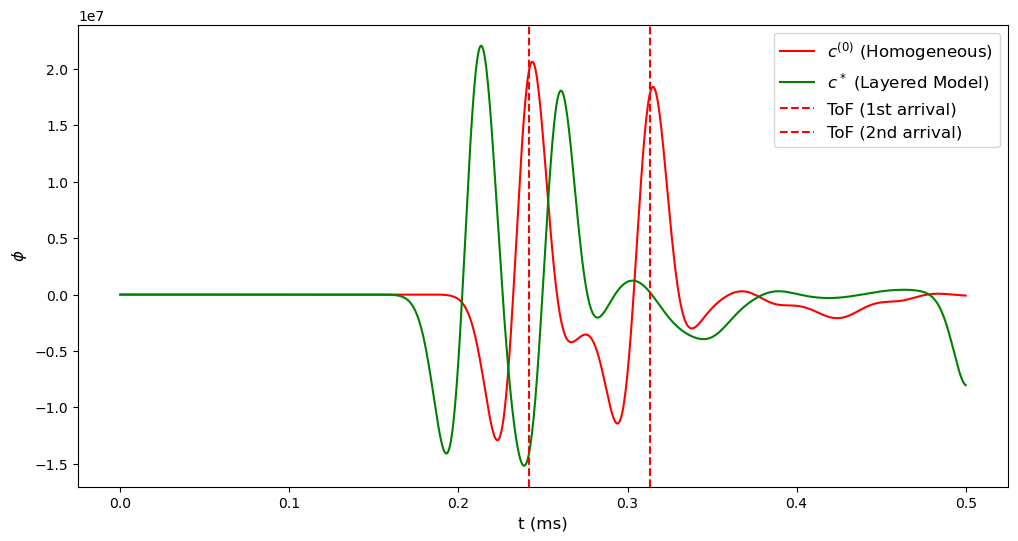

In [94]:
# simulation_name = 'forward_simulation_homogeneous_model'
simulation_name = 'forward_simulation_layred_model'

ed_homo = p.waveforms.get(data_name='forward_simulation_homogeneous_model', events=p.events.list()[0])[0]
ed_layered = p.waveforms.get(data_name='forward_simulation_layred_model', events=p.events.list()[0])[0]

data_homo = ed_homo.get_waveform_data_xarray(receiver_field='phi')
data_layered = ed_layered.get_waveform_data_xarray(receiver_field='phi')
time = data_homo.time


plt.figure(figsize=(12, 6))
t_idx = np.argmax(data_homo[1].values)

plt.plot(time*1e3, data_homo[0], color='red', linestyle='-' ,label=rf'$c^{{(0)}}$ (Homogeneous)')
plt.plot(time*1e3, data_layered[0], color='green', linestyle='-', label=rf'$c^*$ (Layered Model)')




# plt.plot(time*1e3-time_shift_in_seconds*1e3, data_true[1])

plt.axvline(x=math.dist(s_loc, r_loc)/VP*1e3+time[t_idx]*1e3, color='red', linestyle='--', label='ToF (1st arrival)')

plt.axvline(x=math.dist((s_loc[0], -s_loc[1]), r_loc)/VP*1e3+time[t_idx]*1e3, color='red', linestyle='--', label='ToF (2nd arrival)')
plt.legend(fontsize=12)
plt.xlabel('t (ms)', fontsize=12)
plt.ylabel(rf'$\phi$', fontsize=12)

plt.savefig(Path(IMAGE_DIR_WIN, fr'received_signals.png'))


In [95]:
import time

p.add_to_project(
    sn.MisfitConfiguration(
        name="L2",
        observed_data="forward_simulation_layred_model",
        misfit_function="L2",
        receiver_field='phi',
    )
)


while not p.actions.inversion.compute_misfits(
    simulation_configuration="forward_simulation_homogeneous_model", 
    misfit_configuration="L2", 
    events=p.events.list()[0],
    site_name=SITE_NAME,
    ranks_per_job = RANKS
): time.sleep(10.0)


In [96]:
while not p.actions.inversion.compute_gradients(
    simulation_configuration="forward_simulation_homogeneous_model",
    misfit_configuration="L2",
    wavefield_compression=sn.WavefieldCompression(
        forward_wavefield_sampling_interval=10
    ),
    events=p.events.list()[0],
    site_name=SITE_NAME,
    ranks_per_job=4,
): time.sleep(10.0)

p.viz.nb.gradients(
    simulation_configuration="forward_simulation_homogeneous_model",
    misfit_configuration="L2",
    wavefield_compression=sn.WavefieldCompression(
        forward_wavefield_sampling_interval=10
    ),
    events=p.events.list()[0],
)

[2026-03-18 19:05:14,385] INFO: The following events have been simulated before, but checkpoints are not available for this combination of `site_name` and `ranks_per_job` and wavefield compression settings. They will be run again: ['event_singlepair']
[2026-03-18 19:05:14,699] INFO: Submitting job ...
[2026-03-18 19:05:15,183] INFO: Launched simulations for 1 events. Please check again to see if they are finished.
[2026-03-18 19:05:24,392] INFO: Submitting job ...
[2026-03-18 19:05:24,550] INFO: Launched adjoint simulations for 1 events. Please check again to see if they are finished.
